In [1]:
from pathlib import Path

from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from numpy.typing import NDArray
import numpy as np
from scipy.interpolate import griddata

from bloodmoon.coords import angle2shift
from bloodmoon.mask import CodedMaskCamera, codedmask

import darksun as ds
from darksun.benchmarking import source_catalogue_data

ds.show.set_figures_darkbkg()

In [2]:
def load_fits_data(path: Path, ext: int = 1) -> FITS_rec:
    """Loads the FITS file data from chosen extension."""
    return fits.getdata(path, ext=ext, header=False)

def interp(
    x: NDArray,
    y: NDArray,
    energy: NDArray,
) -> NDArray:
    """Interpolates `y` values in given `energy` values."""
    # ...
    # some preprocess (?)
    # ...
    return griddata(x, y, energy, method='linear')

def integrate(arr: NDArray, bins: NDArray) -> float:
    """Integrates input array."""
    return np.cumsum(arr * bins)[-1]

In [3]:
def _config_hist_values(
    x: NDArray,
    y: NDArray,
    interval: tuple[float, float],
) -> tuple[NDArray, NDArray]:
    """
    Extract `x` values in the `interval` range and respective
    values for `y`. Since x represents a binning array, len(x)
    must be equal to len(y) + 1.
    """
    low, high = interval
    band: NDArray = np.where((x >= low) & (x <= high))[0]
    return x[band], y[band[:-1]]

def extract_spectrum(
    data: FITS_rec,
    sourceID: str,
    energy_range: tuple[float, float] = (2.0, 50.0),
) -> tuple[NDArray, NDArray]:
    """
    Extracts source energy bins and spectrum values in specified `energy_range`.
    """
    data_: FITS_rec = source_catalogue_data(sourceID, data)
    energy, spectrum = _config_hist_values(
        data_['ENERGY'], data_['SPECTRUM'], energy_range,
    )
    return energy, spectrum

def compute_source_avgflux(
    spectrum: NDArray,
    energy_bins: NDArray,
) -> float:
    """Computes a source average flux [ph/cm2/s] in given energy range."""
    # - energy values are considered as bins, so we have:
    #   len(energy_bins) = len(spectrum) + 1
    return integrate(spectrum, np.diff(energy_bins))

In [4]:
def _transform(theta_x: float, theta_y: float) -> float:
    """
    Computes transformation between local-frame and polar
    frame. Input angles are in [deg]. The output is the
    tangent of the polar angle wrt the XY plane.
    """
    tan_x, tan_y = map(
        lambda x: np.tan(np.deg2rad(x)), (theta_x, theta_y),
    )
    return np.sqrt(tan_x ** 2 + tan_y ** 2)

def compute_theta(theta_x: float, theta_y: float) -> float:
    """
    Computes the polar angular coord wrt to the xy plane.
    Both `theta_x` and `theta_y` are in [deg].
    Output angle value is in [deg].
    """
    xi: float = _transform(theta_x, theta_y)
    return np.rad2deg(np.atan(xi))

In [5]:
# directory path
#settings_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/camera_settings"
settings_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits/camera_settings"

# files paths
catalogue_path: Path = Path(settings_path, "RXTE-ASM_BeppoSAX-WFC_catalog_new_2-50keV.fits")

detSi_matten_path: Path = Path(settings_path, "detectorSi_absrp.fits")
detBe_dl_filter_path: Path = Path(settings_path, "detectorBe_deadlayer_filter.fits")

maskKapton_mli_path: Path = Path(settings_path, "mask_MLI_Kapton.fits")

- Let's extract first the spectrum of the chosen source and compute its emitted fluence

In [6]:
catalogue: FITS_rec = load_fits_data(catalogue_path)

In [7]:
sourceID: str = 'crab'                              # source ID in the record
energy_range: tuple[float, float] = (2.0, 50.0)     # specifies photons energy range [keV]

energy, spectrum = extract_spectrum(catalogue, sourceID, energy_range)
avg_flux: float = compute_source_avgflux(spectrum, energy)  # [ph/cm2/s]
exposure: float = 1e3                                       # [s]

print(
    f'Energy range: {energy_range} keV\n'
    f'  - Source avg flux:  {' ' * int(np.log10(exposure))}{avg_flux:.4f} ph/cm2/s\n'
    f'  - Source fluence:   {avg_flux * exposure:.4f} ph/cm2\n'
)

if False:
    ds.plot(
        ds.map4plot(
            arrs=spectrum,
            title='Source Spectrum',
            x=energy[:-1],
            xlabel='energy [keV]',
            ylabel='spectrum [ph/cm2/s/keV]',
        ),
    )

Energy range: (2.0, 50.0) keV
  - Source avg flux:     2.7000 ph/cm2/s
  - Source fluence:   2699.9978 ph/cm2



- Let's now compute the counts observed by the camera from the source

- To do that, we have to account for the camera elements that scatters the incoming photons and the detector absorption

- The original source spectrum is modulated by the presence of the camera MLI layer, the micro-meteoroid filter and detector dead layers, and by the detector Si plate:

$$ S_{0}(E) \mapsto \xi(\vec{\theta}, E) \cdot S_{0}(E) $$

with

$$ \xi(\vec{\theta}, E) = \left[ T^{on}_{MLI}(E) \cdot T^{on}_{dl}(E) \right]^{\frac{1}{\text{cos}\theta}} \cdot \left[ 1 - T^{on}_{Si}(E)^{\frac{1}{\text{cos}\theta}} \right] $$

- where $E$ is the incoming photon energy, $\vec{\theta}$ the source angular coords in the camera local-frame system, and $\theta$ the angular polar coords wrt the camera plane.

- when computing the observed counts, we have to account for the effective area seen by the detector $A(\vec{\theta})$, which includes the mask vignetting effects

In [8]:
# load camera and detector transmissions data
detSi_matten: FITS_rec = load_fits_data(detSi_matten_path)
detBe_dl_filter: FITS_rec = load_fits_data(detBe_dl_filter_path)
maskKapton_mli: FITS_rec = load_fits_data(maskKapton_mli_path)

# load camera framework
base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"
UPS_X, UPS_Y = 5, 1
wfm: CodedMaskCamera = codedmask(f'{base_path}/{MASK_FITS}', UPS_X, UPS_Y)

In [ ]:
def config_transmissions(
    energy: NDArray,
) -> tuple[NDArray, NDArray, NDArray]:
    """
    Extracts camera MLI and micro-meteoroid filter + detector
    dead layers transmission and detector mass attenuation
    values and interpolates them wrt the input energy values.
    """
    def extract_values(
        data: FITS_rec,
    ) -> tuple[NDArray, NDArray]:
        """Extracts photons transmission values."""
        return data.field(0), data.field(1)

    # extract MLI, dead layer and meteoroid filter transmissions (ON-AXIS)
    _energy, _mli_transm = extract_values(maskKapton_mli)
    _, _dl_filter_transm = extract_values(detBe_dl_filter)
    # extract detector mass attenuation (ON-AXIS)
    _, _matten = extract_values(detSi_matten)  # [cm2/g]
    # interpolate values for array broadcasting
    mli_transm, dl_filter_transm, matten = map(
        lambda y: interp(_energy, y, energy)[:-1],
        (_mli_transm, _dl_filter_transm, _matten),
    )
    return mli_transm, dl_filter_transm, matten

def get_detector_QE(
    matten: NDArray,
    angle: float,
) -> NDArray:
    """
    Computes detector absorption probability wrt energy and
    direction. The mass attenuation values are in [cm2/g],
    angle in [rad] (polar angle wrt camera plane).
    """
    rho: float = 2.33   # [g/cm3] (from FITS header)
    d: float = 0.045    # [cm]
    return 1.0 - np.exp(-rho * matten * d / np.cos(angle))

def get_instr_transfer_func(
    mli_transmission: NDArray,
    dl_transmission: NDArray,
    matten: NDArray,
    coords: tuple[float, float],
) -> NDArray:
    """
    Computes detector absorption probability wrt energy and
    direction. The mass attenuation values are in [cm2/g],
    coords in [deg] (cam local-frame).
    """
    polar_angle: float = np.deg2rad(compute_theta(*coords))
    # compute MLI and filter/dead layers transmissions (OFF-AXIS)
    trans: NDArray = (
        np.pow(mli_transmission * dl_transmission, 1 / np.cos(polar_angle))
    )
    # compute detector QE (OFF-AXIS)
    detector_qe: NDArray = get_detector_QE(matten, polar_angle)
    return trans * detector_qe

In [ ]:
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import _mask_pattern_projection

def get_effective_area(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    vignetting: bool = True,
) -> float:
    """
    Computes the source effective area on detector in [cm^2].

    Args:
        camera (CodedMaskCamera):
            Instance with camera geometry info.
        shift_x (float):
            Source coord along fine direction in camera local-frame system.
        shift_y (float):
            Source coord along coarse direction in camera local-frame system.
        vignetting (bool, optional (default=`True`)):
            If `True`, the source model will simulate mask vignetting effects.
    
    Returns:
        output (float):
            Source effective area value on detector in [cm^2].
    """
    # pixel area in [cm^2]
    pixel_area: float = (
        1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
    )
    # mask pattern projection WTO detector sp. res.
    sg = _mask_pattern_projection(
        camera, shift_x, shift_y, vignetting, False,
    )
    # extract detector
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = sg[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    return detector.sum() * pixel_area

def compute_source_counts(
    camera: CodedMaskCamera,
    coords: tuple[float, float],
    flux: float,
    exposure: float,
    vignetting: bool = True,
) -> int:
    """
    Computes source counts given its average flux. Input coords
    are in [deg], flux in [ph/cm2/s], and exposure is in [s].
    """
    # open_fraction: float = camera.mask.sum() / camera.mask.size
    coords_ = map(lambda x: angle2shift(camera, x), coords)
    eff_area = get_effective_area(camera, *coords_, vignetting)
    return int(flux * eff_area * exposure)

Energy range: (2.0, 10.0) keV
  - Source avg flux: 1.2796 ph/cm2/s
  - Source obs counts: 94772 ph



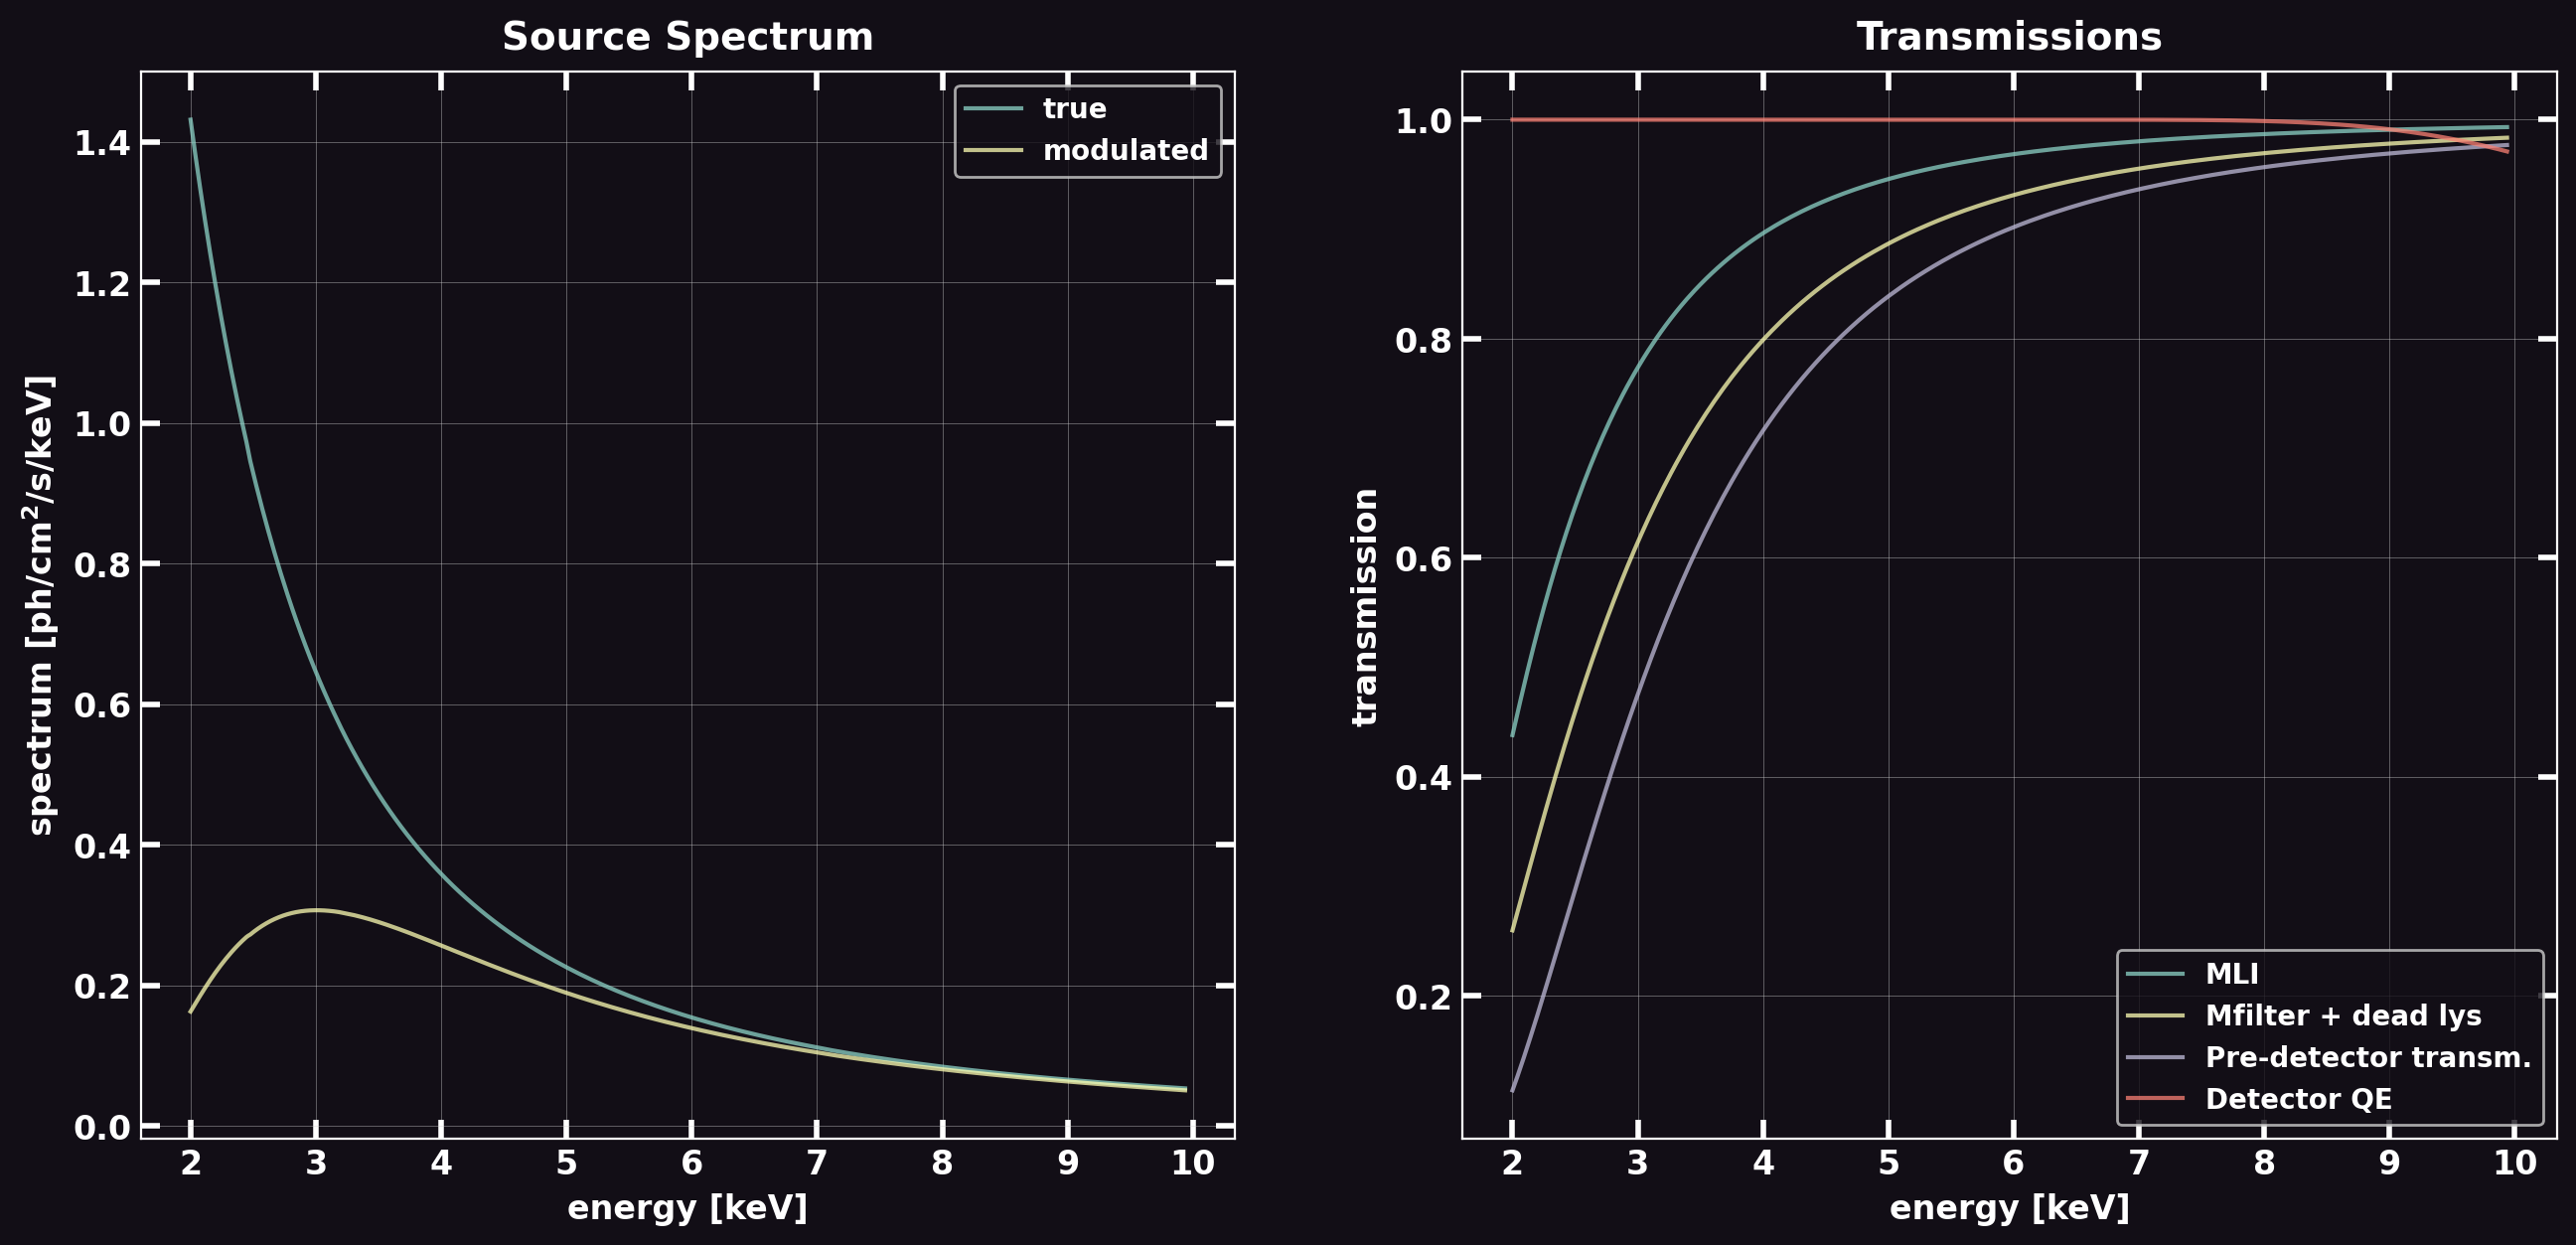

In [ ]:
# extract source spectrum and config transmissions
sourceID: str = 'crab'                              # source ID in the record
energy_range: tuple[float, float] = (2.0, 10.0)     # specifies photons energy range [keV]

energy, spectrum = extract_spectrum(catalogue, sourceID, energy_range)
mli_transm, dl_filter_transm, matten = config_transmissions(energy)

# init source coords
theta_x, theta_y = 0.0, 0.0   # [deg]
exposure: float = 1e3           # [s]

mod_spectr: NDArray = get_instr_transfer_func(mli_transm, dl_filter_transm, matten, (theta_x, theta_y)) * spectrum

avg_flux: float = compute_source_avgflux(mod_spectr, energy)                      # [ph/cm2/s]
counts: int = compute_source_counts(wfm, (theta_x, theta_y), avg_flux, exposure)  # [ph]
print(
    f'Energy range: {energy_range} keV\n'
    f'  - Source avg flux: {avg_flux:.4f} ph/cm2/s\n'
    f'  - Source obs counts: {counts} ph\n'
)

if True:
    polar_angle = np.deg2rad(compute_theta(theta_x, theta_y))
    exp = 1 / np.cos(polar_angle)
    det_qe = get_detector_QE(
        matten=matten,
        angle=polar_angle,
    )
    ds.plot(
        dmaps=(
            ds.map4plot(
                arrs=(spectrum, mod_spectr),
                title='Source Spectrum',
                x=energy[:-1],
                xlabel='energy [keV]',
                ylabel='spectrum [ph/cm$^{2}$/s/keV]',
                labels=('true', 'modulated'),
            ),
            ds.map4plot(
                arrs=(
                    np.pow(mli_transm, exp),
                    np.pow(dl_filter_transm, exp),
                    np.pow(mli_transm * dl_filter_transm, exp),
                    det_qe,
                ),
                title='Transmissions',
                x=energy[:-1],
                xlabel='energy [keV]',
                ylabel='transmission',
                labels=(
                    'MLI',
                    'Mfilter + dead lys',
                    'Pre-detector transm.',
                    'Detector QE'
                ),
            ),
        ),
        ncols=2,
    )